In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/shivamb/netflix-shows/netflix_titles.csv


In [2]:
# ==========================================
# Task 3: Exploratory Data Analysis (EDA)
# Dataset: Netflix Shows Dataset
# ==========================================

# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [3]:


# ------------------------------------------
# Display Available Files
# ------------------------------------------

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


/kaggle/input/datasets/shivamb/netflix-shows/netflix_titles.csv


In [4]:

# ------------------------------------------
# Load Dataset
# ------------------------------------------

# Update path if needed according to your dataset location
df = pd.read_csv('/kaggle/input/datasets/shivamb/netflix-shows/netflix_titles.csv')

print("Dataset Shape:", df.shape)

print("\nFirst 5 Rows:")
print(df.head())


Dataset Shape: (8807, 12)

First 5 Rows:
  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 min   
1  September 24, 2021          2021  TV-MA  2

In [5]:

# ------------------------------------------
# Dataset Information
# ------------------------------------------

print("\nDataset Information:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB
None

Missing Values:
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           

In [6]:

# ------------------------------------------
# Summary Statistics
# ------------------------------------------

print("\nSummary Statistics:")
print(df.describe(include='all'))

# ==========================================
# DATA CLEANING
# ==========================================

# Convert date_added into datetime
df['date_added'] = pd.to_datetime(
    df['date_added'],
    errors='coerce'
)

# Extract Year and Month
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month



Summary Statistics:
       show_id   type                 title       director  \
count     8807   8807                  8807           6173   
unique    8807      2                  8807           4528   
top         s1  Movie  Dick Johnson Is Dead  Rajiv Chilaka   
freq         1   6131                     1             19   
mean       NaN    NaN                   NaN            NaN   
std        NaN    NaN                   NaN            NaN   
min        NaN    NaN                   NaN            NaN   
25%        NaN    NaN                   NaN            NaN   
50%        NaN    NaN                   NaN            NaN   
75%        NaN    NaN                   NaN            NaN   
max        NaN    NaN                   NaN            NaN   

                      cast        country       date_added  release_year  \
count                 7982           7976             8797   8807.000000   
unique                7692            748             1767           NaN   
top   

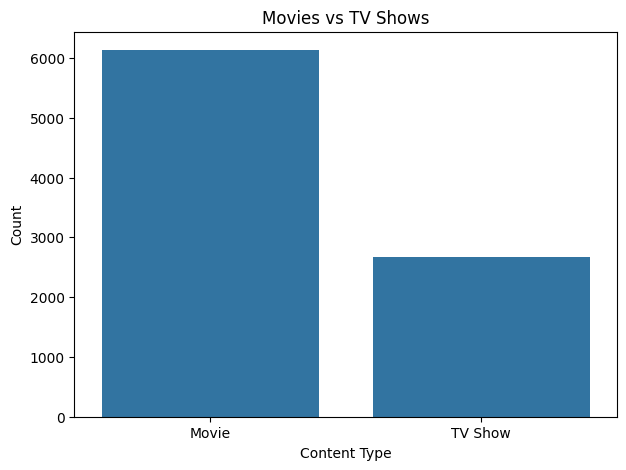

In [7]:

# ==========================================
# VISUALIZATION 1
# Movies vs TV Shows
# ==========================================

plt.figure(figsize=(7,5))

sns.countplot(
    x='type',
    data=df
)

plt.title("Movies vs TV Shows")
plt.xlabel("Content Type")
plt.ylabel("Count")

plt.show()


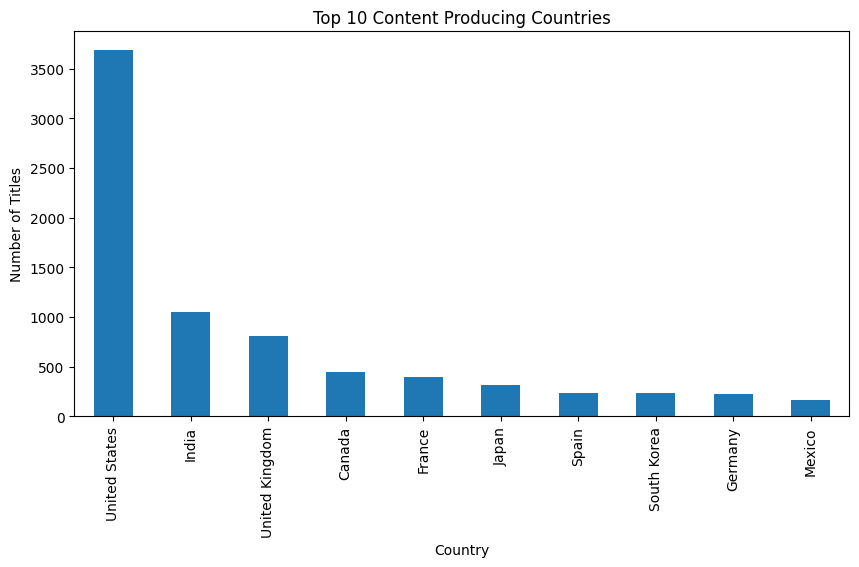

In [8]:
# ==========================================
# VISUALIZATION 2
# Top 10 Countries Producing Netflix Content
# ==========================================

country_count = (
    df['country']
    .dropna()
    .str.split(',')
    .explode()
    .str.strip()
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10,5))

country_count.plot(kind='bar')

plt.title("Top 10 Content Producing Countries")
plt.xlabel("Country")
plt.ylabel("Number of Titles")

plt.show()


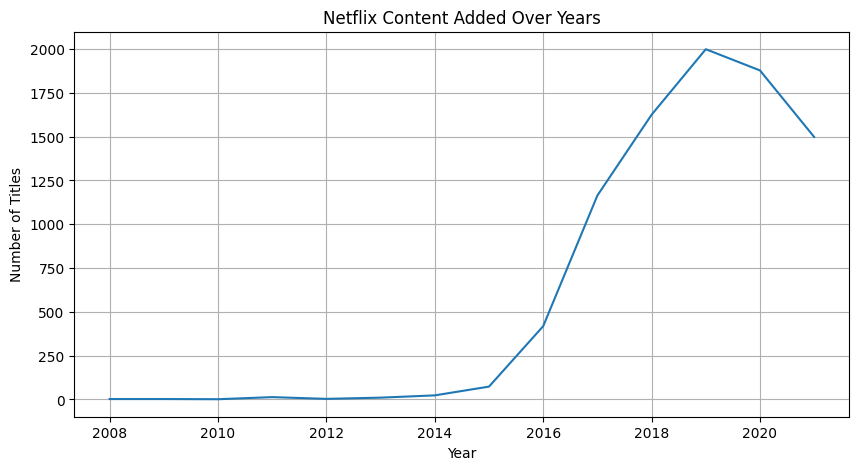

In [9]:

# ==========================================
# VISUALIZATION 3
# Content Added Over Years
# ==========================================

plt.figure(figsize=(10,5))

df['year_added'].value_counts().sort_index().plot()

plt.title("Netflix Content Added Over Years")
plt.xlabel("Year")
plt.ylabel("Number of Titles")

plt.grid(True)

plt.show()


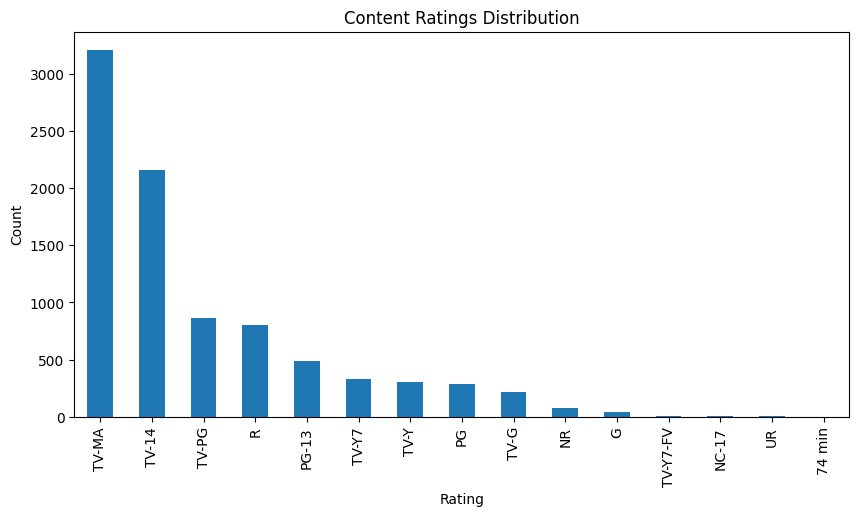

In [10]:


# ==========================================
# VISUALIZATION 4
# Rating Distribution
# ==========================================

plt.figure(figsize=(10,5))

df['rating'].value_counts().head(15).plot(
    kind='bar'
)

plt.title("Content Ratings Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")

plt.show()


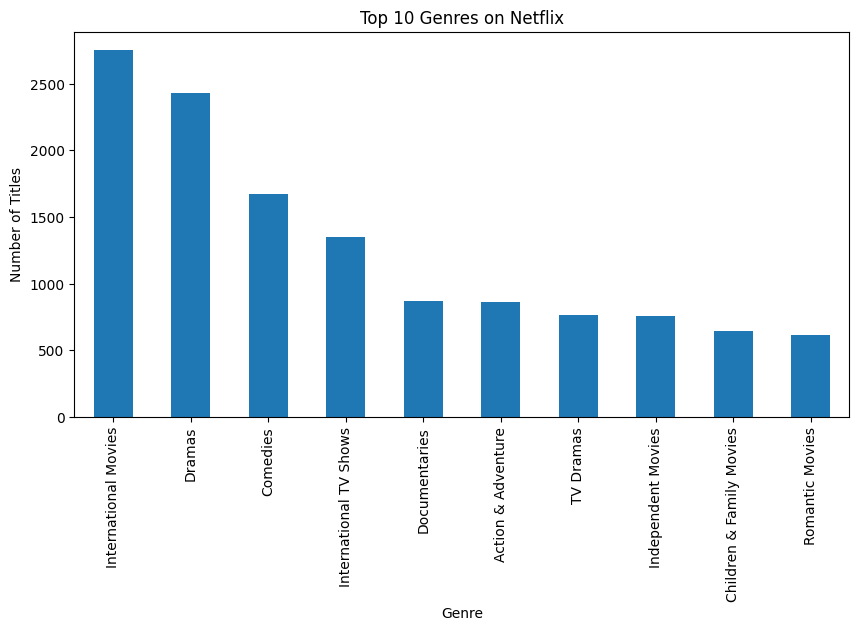

In [11]:

# ==========================================
# VISUALIZATION 5
# Top Genres
# ==========================================

genres = (
    df['listed_in']
    .str.split(',')
    .explode()
    .str.strip()
)

top_genres = genres.value_counts().head(10)

plt.figure(figsize=(10,5))

top_genres.plot(kind='bar')

plt.title("Top 10 Genres on Netflix")
plt.xlabel("Genre")
plt.ylabel("Number of Titles")

plt.show()


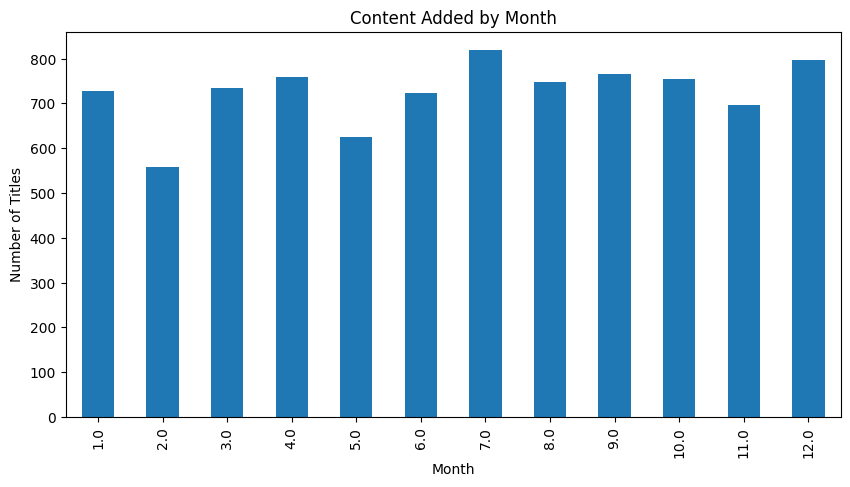

In [12]:

# ==========================================
# VISUALIZATION 6
# Monthly Trend of Content Addition
# ==========================================

plt.figure(figsize=(10,5))

df['month_added'].value_counts()\
    .sort_index()\
    .plot(kind='bar')

plt.title("Content Added by Month")
plt.xlabel("Month")
plt.ylabel("Number of Titles")

plt.show()


<>:9: SyntaxWarning: invalid escape sequence '\d'
<>:9: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_58/987260587.py:9: SyntaxWarning: invalid escape sequence '\d'
  .str.extract('(\d+)')



Correlation Matrix:
              release_year  year_added  month_added  duration_num
release_year      1.000000    0.110473    -0.039316     -0.249182
year_added        0.110473    1.000000    -0.160555      0.016436
month_added      -0.039316   -0.160555     1.000000     -0.016876
duration_num     -0.249182    0.016436    -0.016876      1.000000


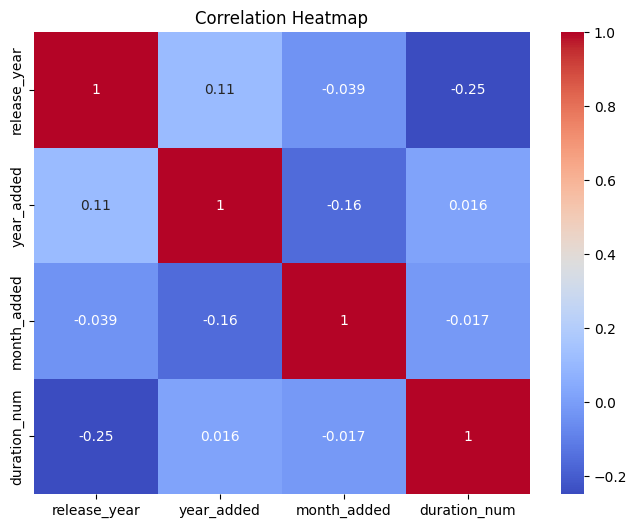

In [13]:

# ==========================================
# Correlation Analysis
# ==========================================

# Extract Duration Number

df['duration_num'] = (
    df['duration']
    .str.extract('(\d+)')
)

df['duration_num'] = pd.to_numeric(
    df['duration_num'],
    errors='coerce'
)

# Numerical Columns

numeric_df = df[['release_year', 'year_added', 'month_added', 'duration_num']]

# Correlation Matrix

corr_matrix = numeric_df.corr()

print("\nCorrelation Matrix:")
print(corr_matrix)

# Correlation Heatmap

plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()


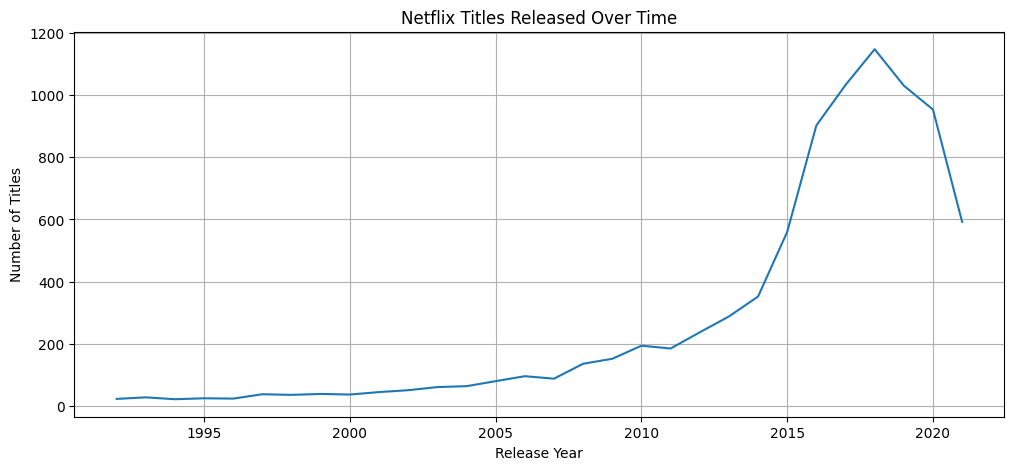

In [14]:

# ==========================================
# Trend Analysis:
# Content Growth by Release Year
# ==========================================

plt.figure(figsize=(12,5))

df['release_year']\
    .value_counts()\
    .sort_index()\
    .tail(30)\
    .plot()

plt.title("Netflix Titles Released Over Time")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")

plt.grid(True)

plt.show()


In [15]:

# ==========================================
# Insights
# ==========================================

print("\n========== KEY INSIGHTS ==========")

print("""
1. Movies significantly outnumber TV Shows.

2. United States contributes the highest amount
   of Netflix content.

3. Netflix experienced rapid content growth
   after 2015.

4. TV-MA and TV-14 are among the most common ratings.

5. International Movies and Dramas are among
   the most popular genres.

6. Most content was added between 2017 and 2020.

7. Content additions peak during certain months,
   indicating seasonal upload patterns.

8. Release year and year added show positive
   correlation, meaning newer content is added
   more frequently.
""")

print("\nEDA Completed Successfully!")


========== KEY INSIGHTS ==========

1. Movies significantly outnumber TV Shows.

2. United States contributes the highest amount
   of Netflix content.

3. Netflix experienced rapid content growth
   after 2015.

4. TV-MA and TV-14 are among the most common ratings.

5. International Movies and Dramas are among
   the most popular genres.

6. Most content was added between 2017 and 2020.

7. Content additions peak during certain months,
   indicating seasonal upload patterns.

8. Release year and year added show positive
   correlation, meaning newer content is added
   more frequently.


EDA Completed Successfully!
